In [90]:
import pandas as pd 
import numpy  as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [135]:
# importar data y filtrar por uk 
data = pd.read_excel('./data/online_retail_II.xlsx')
data = data[data.Country == 'United Kingdom']
data.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2357,489597,85217,ASSORTED ICE CREAM FRIDGE MAGNETS,1,2009-12-01 14:28:00,7.78,NaN,United Kingdom
70108,495677,85123A,WHITE HANGING HEART T-LIGHT HOLDER,12,2010-01-26 11:32:00,2.95,14211.0,United Kingdom
88282,497632,22416,36 DOILIES SPACEBOY DESIGN,3,2010-02-11 13:41:00,1.45,16918.0,United Kingdom
182706,506724,84908B,BLUE 5 PATCH FLOWER CUSHION COVER,2,2010-05-04 10:02:00,5.91,NaN,United Kingdom
391490,527051,21830,ASSORTED CREEPY CRAWLIES,24,2010-10-14 13:00:00,0.42,13395.0,United Kingdom


In [136]:
# revisar los tipos de datos del dataset 
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 485852 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      485852 non-null  object        
 1   StockCode    485852 non-null  object        
 2   Description  482924 non-null  object        
 3   Quantity     485852 non-null  int64         
 4   InvoiceDate  485852 non-null  datetime64[ns]
 5   Price        485852 non-null  float64       
 6   Customer ID  379423 non-null  float64       
 7   Country      485852 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.4+ MB


In [137]:
# revisar valores nulos 
(data.isnull().sum() / data.shape[0]) * 100

Invoice         0.000000
StockCode       0.000000
Description     0.602653
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    21.905642
Country         0.000000
dtype: float64

In [138]:
# Normalizar la fecha 
data['fecha_norm'] = data['InvoiceDate'].dt.normalize()

In [159]:
### CREAR VARIABLES! 
data['total_price'] = data['Quantity'] * data['Price']
data = data[data['total_price'] > 0]

# 1. Total cantidades por clientes 
total_quant_per_client = data.groupby(['Customer ID','fecha_norm']).agg(
        total_quantity = ('Quantity','sum')
).reset_index()

# validar valores positivos 
total_quant_per_client = total_quant_per_client[total_quant_per_client['total_quantity']>0]

# total de cantidades de cliente por dia 
total_quant_per_client = (data.groupby(['Customer ID','fecha_norm'])
                          .agg(total_quantity=('Quantity','sum'))
                          .reset_index()
                         )
# Min, max y promedio 
quantity_features = (
    total_quant_per_client.groupby('Customer ID')
    .agg(
        min_quantity=('total_quantity','min'),
        max_quantity=('total_quantity','max'),
        mean_quantity=('total_quantity','mean')
    ).reset_index()
)

# Min, max y promedio del price por boleta 
total_price_per_invoice = (data.groupby(['Customer ID','Invoice'])['Price']
                            .sum().reset_index()
                            .groupby(['Customer ID']).agg(
                                max_total_invoice = ('Price','max'),
                                min_total_invoice = ('Price','min'),
                                mean_total_invoice = ('Price','mean')
                            ).reset_index()
                          )


# Monto total historico 
gasto_total = (data.groupby(['Customer ID'])['total_price'].sum().reset_index())

# Features de frecuencia 
compras = (data.groupby(['Customer ID','Invoice'])
                .agg(fecha_compra=('fecha_norm','min'))
                .reset_index()
                .sort_values(['Customer ID','fecha_compra'])
          )

compras['dias_entre_compras'] = (compras.groupby('Customer ID')['fecha_compra']
                                .diff()
                                .dt.days)

compras = compras.dropna(subset='dias_entre_compras')

temporal_features = (
    compras.groupby(['Customer ID']).
        agg(
            mean_freq_purchase = ('dias_entre_compras','mean'),
            std_freq_purchase = ('dias_entre_compras','std'),
            freq_total = ('Invoice','nunique')
        ).
        reset_index()
)

# total dias desde su ultima compra 
fecha_max = compras['fecha_compra'].max()

recency = (
    compras.groupby(['Customer ID'])['fecha_compra']
        .max()
        .apply(lambda x : (fecha_max - x).days)
        .reset_index(name='recency')
)


features_final = (quantity_features.merge(total_price_per_invoice,on='Customer ID',how='inner') 
                              .merge(gasto_total,on='Customer ID',how='inner') 
                              .merge(temporal_features, on='Customer ID', how='inner') 
                              .merge(recency, on='Customer ID',how='inner'))

for col in [
    'mean_freq_purchase', 'mean_quantity', 'mean_total_invoice', 'total_price'
]:
    p95 = features_final[col].quantile(0.95)
    features_final = features_final[features_final[col] <= p95]

features_final = features_final.fillna(0)

features_final

,Customer ID,min_quantity,max_quantity,mean_quantity,max_total_invoice,min_total_invoice,mean_total_invoice,total_price,mean_freq_purchase,std_freq_purchase,freq_total,recency
0,12346.0,5,20,10.000000,142.31,1.00,18.760000,372.86,19.600000,36.624825,10,164
1,12745.0,199,268,233.500000,37.77,30.21,33.990000,723.85,88.000000,0.000000,1,121
2,12747.0,38,201,92.687500,72.74,21.13,41.619375,5080.53,24.200000,16.288471,15,4
5,12820.0,45,369,177.428571,62.10,12.30,40.520000,1747.18,56.166667,29.748389,6,32
6,12823.0,30,250,70.000000,7.65,5.95,6.619231,4742.00,23.750000,21.157956,12,29
...,...,...,...,...,...,...,...,...,...,...,...,...
2659,18275.0,193,224,208.500000,25.41,21.88,23.645000,741.85,153.000000,0.000000,1,213
2660,18276.0,159,260,212.000000,55.84,11.08,36.594000,1320.66,84.250000,37.748068,4,27
2661,18277.0,100,171,127.000000,95.89,42.43,74.367500,1069.67,32.333333,40.673497,3,32
2662,18283.0,32,118,67.200000,125.85,14.30,83.136667,641.77,55.200000,61.892649,5,17


In [87]:
data_final.isnull().sum()


(2665, 10)

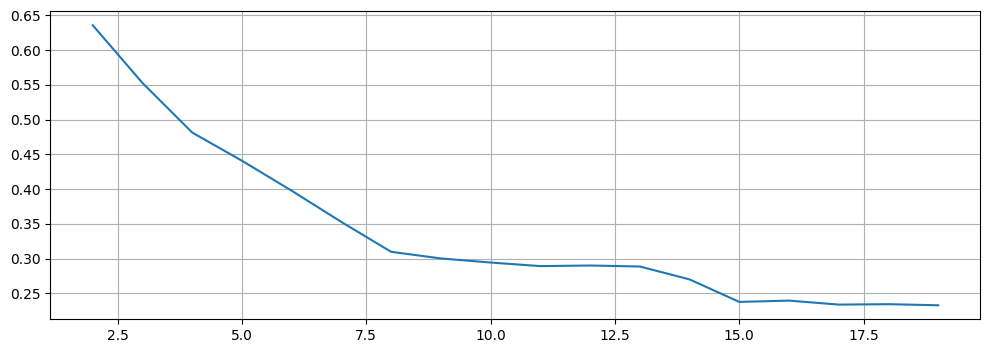

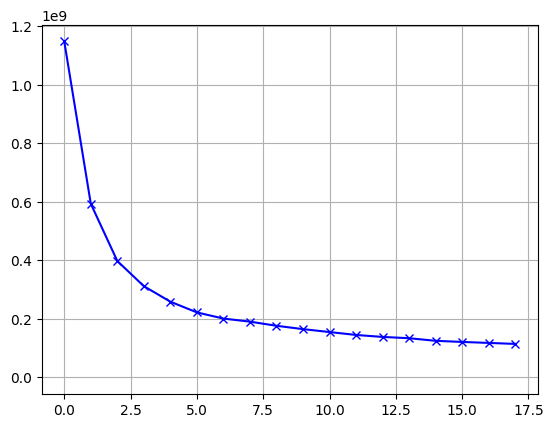

In [160]:
# aplicar KMEANS

features = features_final.drop('Customer ID',axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# obtener el numero de K optimi 
scores = []
inertia = []
for k in range(2,20):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(features)
    scores.append(silhouette_score(features, labels))
    inertia.append(kmeans.inertia_)

fix, ax = plt.subplots(figsize=(12,4))
ax.plot(np.arange(2,20), scores)
plt.grid()
plt.show()

# graficar codo 
plt.plot(1, 10, inertia,'bx-')
plt.grid()


In [164]:
kmeans = KMeans(n_clusters=3,random_state=42)
labels = kmeans.fit_predict(features)
labels

array([0, 0, 1, ..., 0, 0, 2], shape=(2169,), dtype=int32)

In [165]:
features_final["clusters"] = labels
features_final

,Customer ID,min_quantity,max_quantity,mean_quantity,max_total_invoice,min_total_invoice,mean_total_invoice,total_price,mean_freq_purchase,std_freq_purchase,freq_total,recency,clusters,tsne_1,tsne_2
0,12346.0,5,20,10.000000,142.31,1.00,18.760000,372.86,19.600000,36.624825,10,164,0,-5.713483,4.924708
1,12745.0,199,268,233.500000,37.77,30.21,33.990000,723.85,88.000000,0.000000,1,121,0,-4.796806,-2.884534
2,12747.0,38,201,92.687500,72.74,21.13,41.619375,5080.53,24.200000,16.288471,15,4,1,8.747808,-1.534940
5,12820.0,45,369,177.428571,62.10,12.30,40.520000,1747.18,56.166667,29.748389,6,32,2,4.877516,0.477373
6,12823.0,30,250,70.000000,7.65,5.95,6.619231,4742.00,23.750000,21.157956,12,29,1,8.592078,-1.327620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,18275.0,193,224,208.500000,25.41,21.88,23.645000,741.85,153.000000,0.000000,1,213,0,-6.438462,-3.939542
2660,18276.0,159,260,212.000000,55.84,11.08,36.594000,1320.66,84.250000,37.748068,4,27,0,0.888323,-0.806662
2661,18277.0,100,171,127.000000,95.89,42.43,74.367500,1069.67,32.333333,40.673497,3,32,0,-0.854895,0.342270
2662,18283.0,32,118,67.200000,125.85,14.30,83.136667,641.77,55.200000,61.892649,5,17,0,0.688255,3.316509


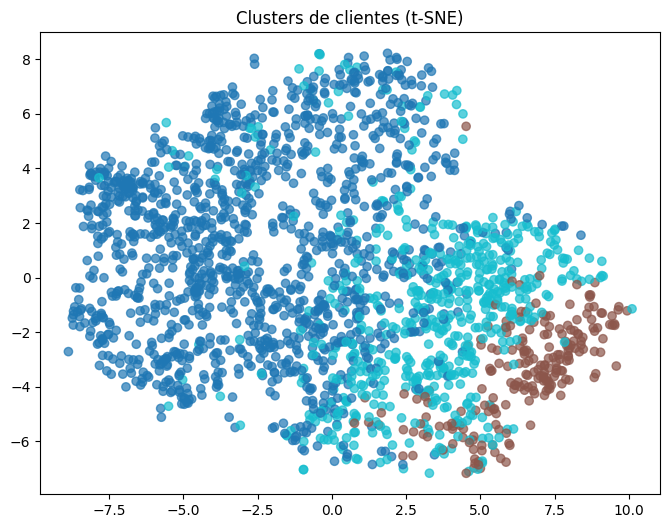

In [166]:
# t-nse 
tsne = TSNE(n_components=3, random_state=42, perplexity=100)
X_tsne = tsne.fit_transform(X_scaled)

features_final['tsne_1'] = X_tsne[:, 0]
features_final['tsne_2'] = X_tsne[:, 1]


plt.figure(figsize=(8,6))
plt.scatter(features_final['tsne_1'], features_final['tsne_2'], c=features_final['clusters'], cmap='tab10', alpha=0.7)
plt.title('Clusters de clientes (t-SNE)')
plt.show()

In [168]:
features_final.clusters.value_counts()

clusters
0    1341
2     613
1     215
Name: count, dtype: int64

In [ ]:
# TODO: Guardar modelo en carpeta